# C-GASTON — All Result Visualizations
**Sharvani Sinha — EECS 545**

Generates all figures for the final report:
1. Per-slice ARI comparison (GASTON vs C-GASTON Std vs Soft)
2. Backbone comparison bar chart (ResNet-50 vs UNI vs CONCH)
3. Ablation study plots (λ sweep, σ sweep)
4. Spatial domain maps (GT vs predicted isodepth)
5. Boundary Precision@50µm comparison
6. Per-layer F1 heatmap
7. Moran's I comparison
8. Training loss curves

## Step 0: Install + Mount

In [1]:
import subprocess, sys
def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])
pip('anndata', 'scanpy', 'scipy', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas')
pip('gaston-spatial')
print('Done.')

Done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Mounted.')

Mounted at /content/drive
Mounted.


## Step 1: Imports

In [3]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})
COLORS = {
    'gaston':      '#4C72B0',
    'cgaston_std': '#DD8452',
    'cgaston_soft':'#55A868',
    'resnet':      '#8172B2',
    'uni':         '#C44E52',
    'conch':       '#64B5CD',
}
print('Imports done.')

Imports done.


## Step 2: Configuration — edit paths here

In [4]:
BASE_DIR       = '/content/drive/MyDrive/EECS 545 Project'
GLMPCA_DIR     = '/content/drive/MyDrive/EECS545_glmpca_results'
HE_BASE_DIR    = f'{BASE_DIR}/DLPFC_Datasets(raw data)'
SAMPLE1_DIR    = f'{HE_BASE_DIR}/Sample1/h5ad_cordintae_data'
SAMPLE3_DIR    = f'{HE_BASE_DIR}/Sample3/h5ad_cordinate_data'

GASTON_DIR     = '/content/drive/MyDrive/Evaluation_Comparison/gaston_baseline_all8'
CONCH_STD_DIR  = '/content/drive/MyDrive/C_GASTON_results_conch'
CONCH_SOFT_DIR = '/content/drive/MyDrive/C_GASTON_results_conch_soft'
UNI_STD_DIR    = '/content/drive/MyDrive/C_GASTON_results/standard'

FIG_DIR = '/content/drive/MyDrive/C_GASTON_figures'
os.makedirs(FIG_DIR, exist_ok=True)

ALL_SLICES = ['151507','151508','151509','151510',
              '151673','151674','151675','151676']
SLICE_DATA_DIRS = {
    '151507': SAMPLE1_DIR, '151508': SAMPLE1_DIR,
    '151509': SAMPLE1_DIR, '151510': SAMPLE1_DIR,
    '151673': SAMPLE3_DIR, '151674': SAMPLE3_DIR,
    '151675': SAMPLE3_DIR, '151676': SAMPLE3_DIR,
}
LABEL_TO_INT = {'L1':0,'L2':1,'L3':2,'L4':3,'L5':4,'L6':5,'WM':6}
INT_TO_LABEL = {v:k for k,v in LABEL_TO_INT.items()}
NUM_LAYERS   = 7
LAYER_NAMES  = ['L1','L2','L3','L4','L5','L6','WM']
print('Config loaded. Figures will be saved to:', FIG_DIR)

Config loaded. Figures will be saved to: /content/drive/MyDrive/C_GASTON_figures


## Step 3: Load coords + ground truth

In [5]:
data = {}
for sid in ALL_SLICES:
    adata  = ad.read_h5ad(f'{SLICE_DATA_DIRS[sid]}/{sid}.h5ad')
    adata.var_names_make_unique()
    S      = np.asarray(adata.obsm['spatial'])
    gt_str = adata.obs['original_domain'].astype(str).values
    gt_int = np.array([LABEL_TO_INT.get(l,-1) for l in gt_str])
    data[sid] = {'coords': S, 'gt_labels': gt_int}
    print(f'  {sid}: {S.shape[0]} spots')
print('[OK]')

  151507: 4221 spots
  151508: 4381 spots
  151509: 4788 spots
  151510: 4595 spots
  151673: 3611 spots
  151674: 3635 spots
  151675: 3566 spots
  151676: 3431 spots
[OK]


## Step 4: Load all saved predictions

In [6]:
def load_preds(base_dir, iso_file, label_file):
    """Load isodepth + label arrays for all slices from a results directory."""
    preds = {}
    for sid in ALL_SLICES:
        iso_path   = f'{base_dir}/{sid}/{iso_file}'
        label_path = f'{base_dir}/{sid}/{label_file}'
        if os.path.isfile(iso_path) and os.path.isfile(label_path):
            preds[sid] = {
                'isodepth': np.load(iso_path),
                'labels':   np.load(label_path).astype(int),
            }
        else:
            print(f'  WARNING: missing files for {sid} in {base_dir}')
    return preds

preds_gaston    = load_preds(GASTON_DIR,     'gaston_isodepth.npy',      'gaston_labels.npy')
preds_conch_std = load_preds(CONCH_STD_DIR,  'cgaston_isodepth.npy',     'cgaston_labels.npy')
preds_conch_soft= load_preds(CONCH_SOFT_DIR, 'cgaston_soft_isodepth.npy','cgaston_soft_labels.npy')
preds_uni_std   = load_preds(UNI_STD_DIR,    'cgaston_isodepth.npy',     'cgaston_labels.npy')

print('Predictions loaded.')

Predictions loaded.


## Figure 1: Per-slice ARI — GASTON vs C-GASTON Std vs Soft
The main result comparison figure.

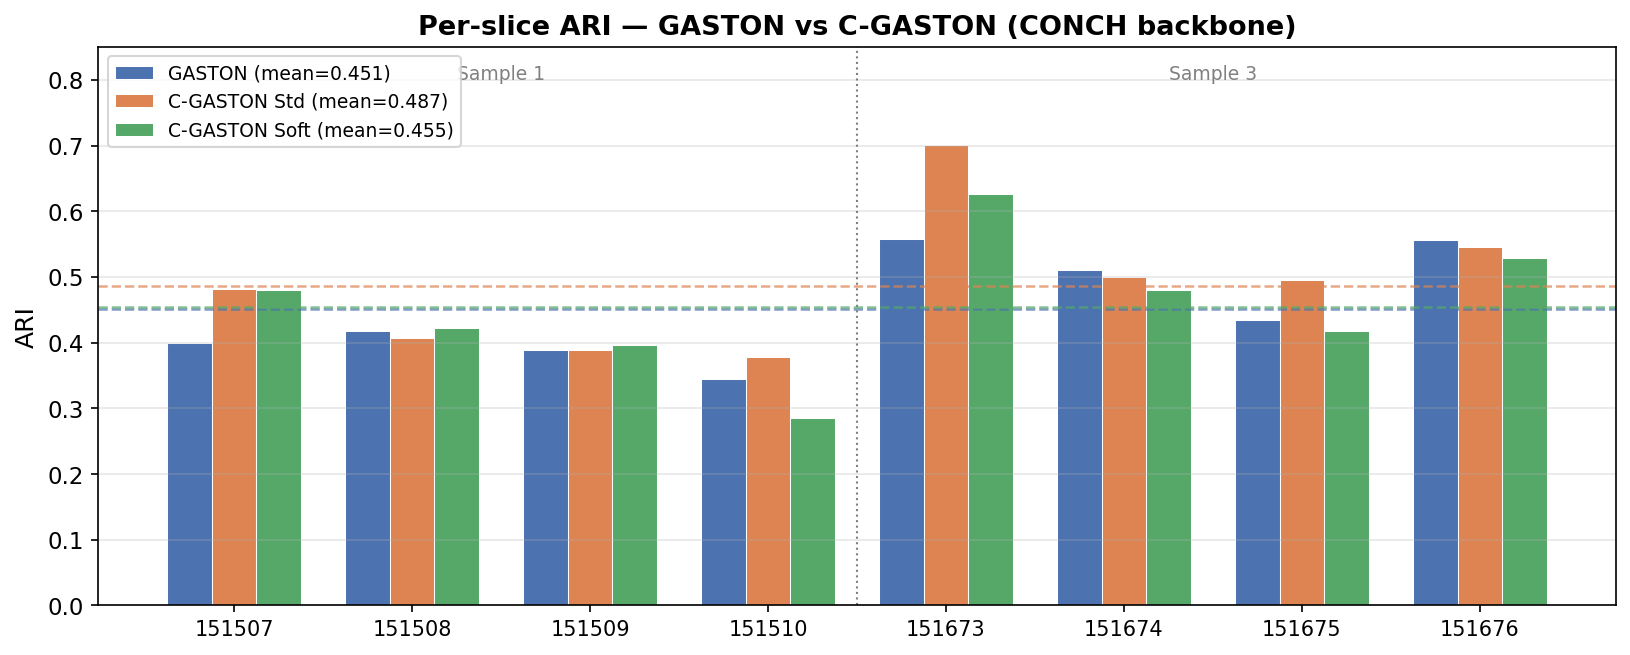

Saved: fig1_ari_per_slice.png


In [7]:
from sklearn.metrics import adjusted_rand_score

# Hardcoded from notebook outputs (already verified)
ari_data = {
    'GASTON':         [0.3998,0.4174,0.3891,0.3448,0.5575,0.5112,0.4342,0.5567],
    'C-GASTON Std':   [0.4819,0.4076,0.3884,0.3775,0.7003,0.4997,0.4949,0.5451],
    'C-GASTON Soft':  [0.4796,0.4216,0.3971,0.2860,0.6266,0.4806,0.4184,0.5293],
}

x      = np.arange(len(ALL_SLICES))
w      = 0.25
fig, ax = plt.subplots(figsize=(11, 4.5))

for i, (method, aris) in enumerate(ari_data.items()):
    color = [COLORS['gaston'], COLORS['cgaston_std'], COLORS['cgaston_soft']][i]
    bars  = ax.bar(x + (i-1)*w, aris, w, label=f'{method} (mean={np.mean(aris):.3f})',
                   color=color, edgecolor='white', linewidth=0.5)

# Mean lines
for i, (method, aris) in enumerate(ari_data.items()):
    color = [COLORS['gaston'], COLORS['cgaston_std'], COLORS['cgaston_soft']][i]
    ax.axhline(np.mean(aris), color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(ALL_SLICES, fontsize=10)
ax.set_ylabel('ARI', fontsize=12)
ax.set_title('Per-slice ARI — GASTON vs C-GASTON (CONCH backbone)', fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.axvline(3.5, color='grey', linestyle=':', linewidth=1)  # sample boundary
ax.text(1.5, 0.80, 'Sample 1', ha='center', color='grey', fontsize=9)
ax.text(5.5, 0.80, 'Sample 3', ha='center', color='grey', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_ari_per_slice.png')
plt.show()
print('Saved: fig1_ari_per_slice.png')

## Figure 2: Backbone Comparison
ResNet-50 vs UNI vs CONCH across ARI, NMI, Spearman.

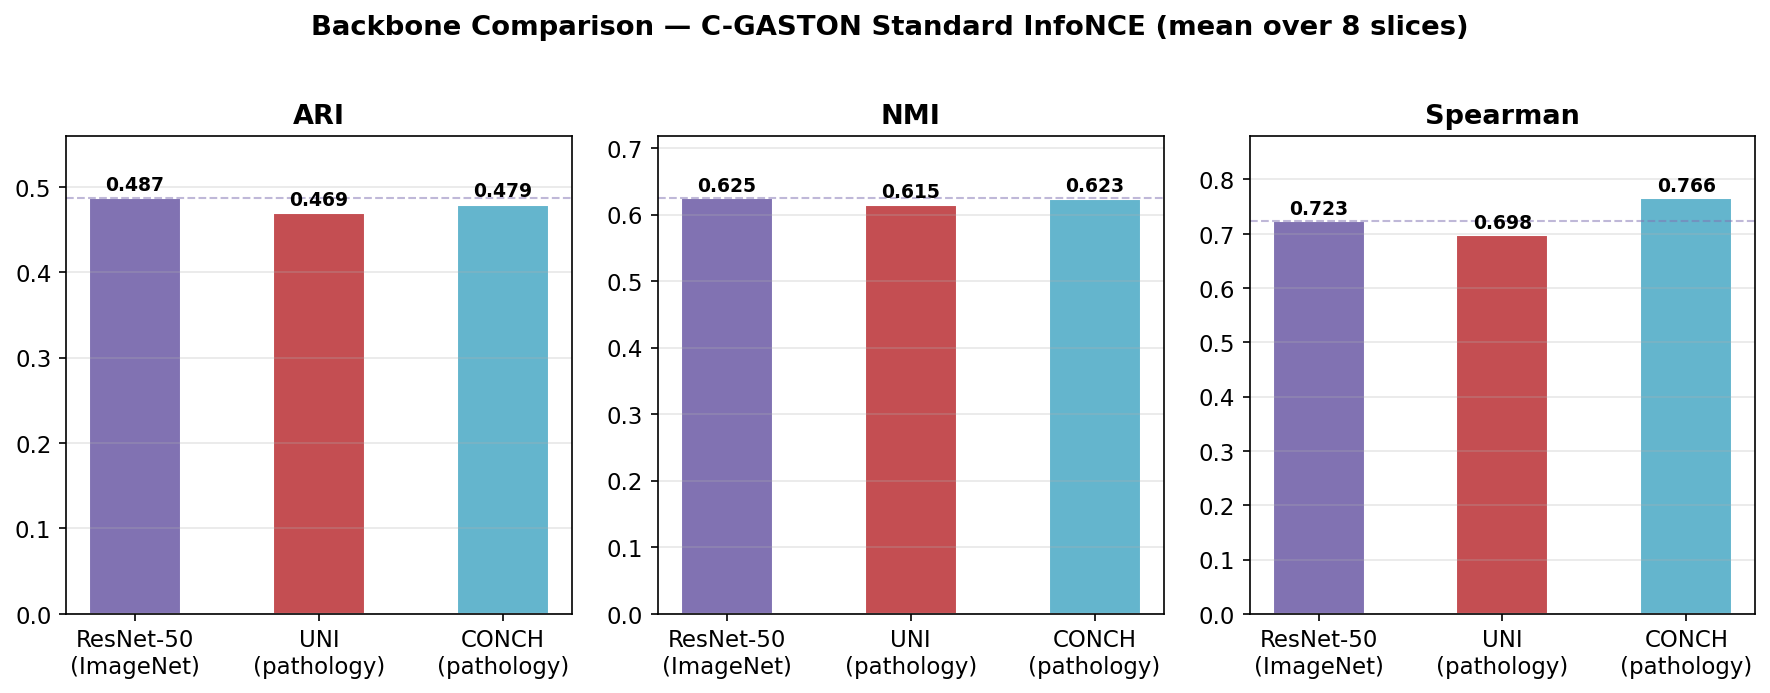

Saved: fig2_backbone_comparison.png
NOTE: Moran's I not plotted yet — fill in the None values once computed.


In [8]:
# Values from Backbone comparison sheet
# Fill in UNI and CONCH Moran's I once computed
backbones = ['ResNet-50\n(ImageNet)', 'UNI\n(pathology)', 'CONCH\n(pathology)']
metrics   = {
    'ARI':       [0.4869, 0.4691, 0.4792],
    'NMI':       [0.6247, 0.6147, 0.6234],
    'Spearman':  [0.7229, 0.6977, 0.7657],
    "Moran's I": [0.9940, None,   None  ],  # fill in after running Moran's I cell
}
colors = [COLORS['resnet'], COLORS['uni'], COLORS['conch']]

plot_metrics = {k:v for k,v in metrics.items() if None not in v}
n_metrics = len(plot_metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4*n_metrics, 4.5))
if n_metrics == 1:
    axes = [axes]

for ax, (metric, vals) in zip(axes, plot_metrics.items()):
    bars = ax.bar(backbones, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, min(1.0, max(vals)*1.15))
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(vals[0], color=COLORS['resnet'], linestyle='--',
               linewidth=1, alpha=0.5, label='ResNet-50 baseline')

plt.suptitle('Backbone Comparison — C-GASTON Standard InfoNCE (mean over 8 slices)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_backbone_comparison.png')
plt.show()
print('Saved: fig2_backbone_comparison.png')
print('NOTE: Moran\'s I not plotted yet — fill in the None values once computed.')

## Figure 3: Ablation — λ sweep
From the Ablation sheet.

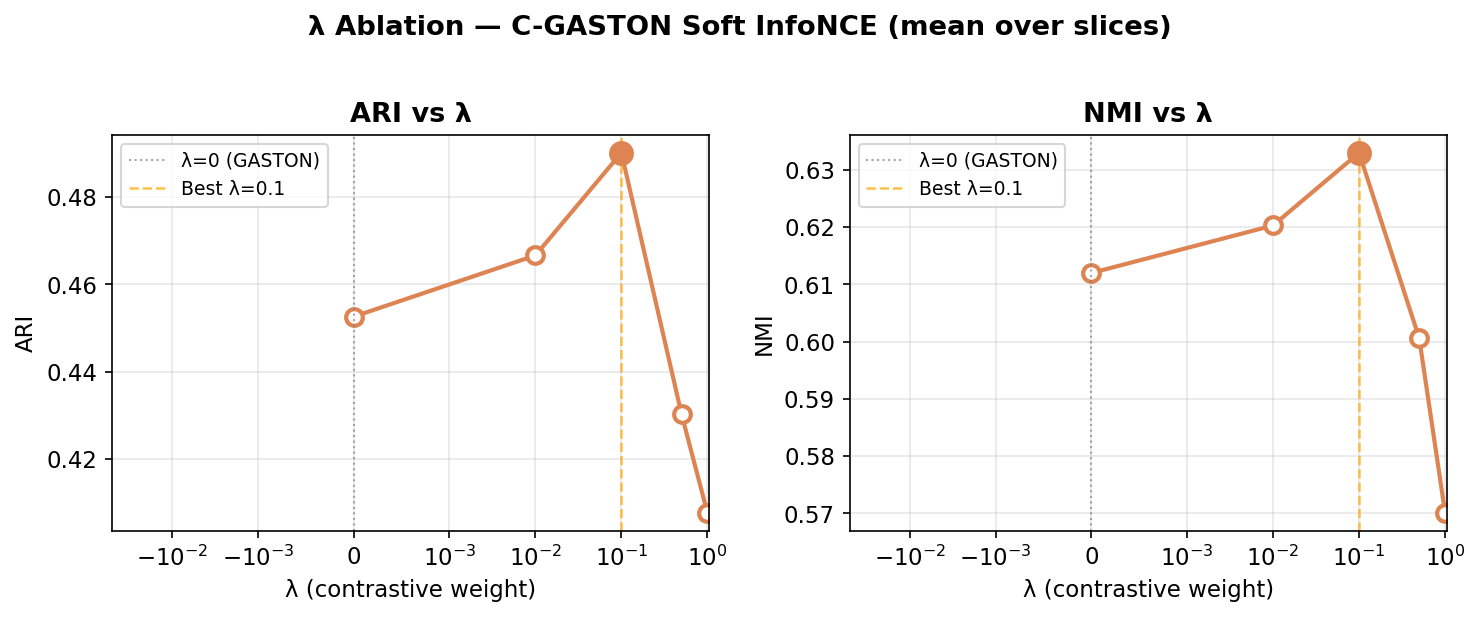

Saved: fig3_lambda_ablation.png


In [9]:
lambda_vals = [0.000, 0.010, 0.100, 0.500, 1.000]
lambda_ari  = [0.4526, 0.4666, 0.4901, 0.4303, 0.4077]
lambda_nmi  = [0.6120, 0.6203, 0.6330, 0.6006, 0.5701]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, vals, ylabel in zip(axes, [lambda_ari, lambda_nmi], ['ARI', 'NMI']):
    ax.plot(lambda_vals, vals, 'o-', color=COLORS['cgaston_std'],
            linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    # highlight best
    best_idx = np.argmax(vals)
    ax.scatter(lambda_vals[best_idx], vals[best_idx],
               s=120, color=COLORS['cgaston_std'], zorder=5)
    ax.axvline(0, color='grey', linestyle=':', linewidth=1, alpha=0.7, label='λ=0 (GASTON)')
    ax.axvline(lambda_vals[best_idx], color='orange', linestyle='--',
               linewidth=1.2, alpha=0.7, label=f'Best λ={lambda_vals[best_idx]}')
    ax.set_xlabel('λ (contrastive weight)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} vs λ', fontweight='bold')
    ax.set_xscale('symlog', linthresh=0.001)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('λ Ablation — C-GASTON Soft InfoNCE (mean over slices)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_lambda_ablation.png')
plt.show()
print('Saved: fig3_lambda_ablation.png')

## Figure 4: Ablation — σ sweep (soft weighting bandwidth)

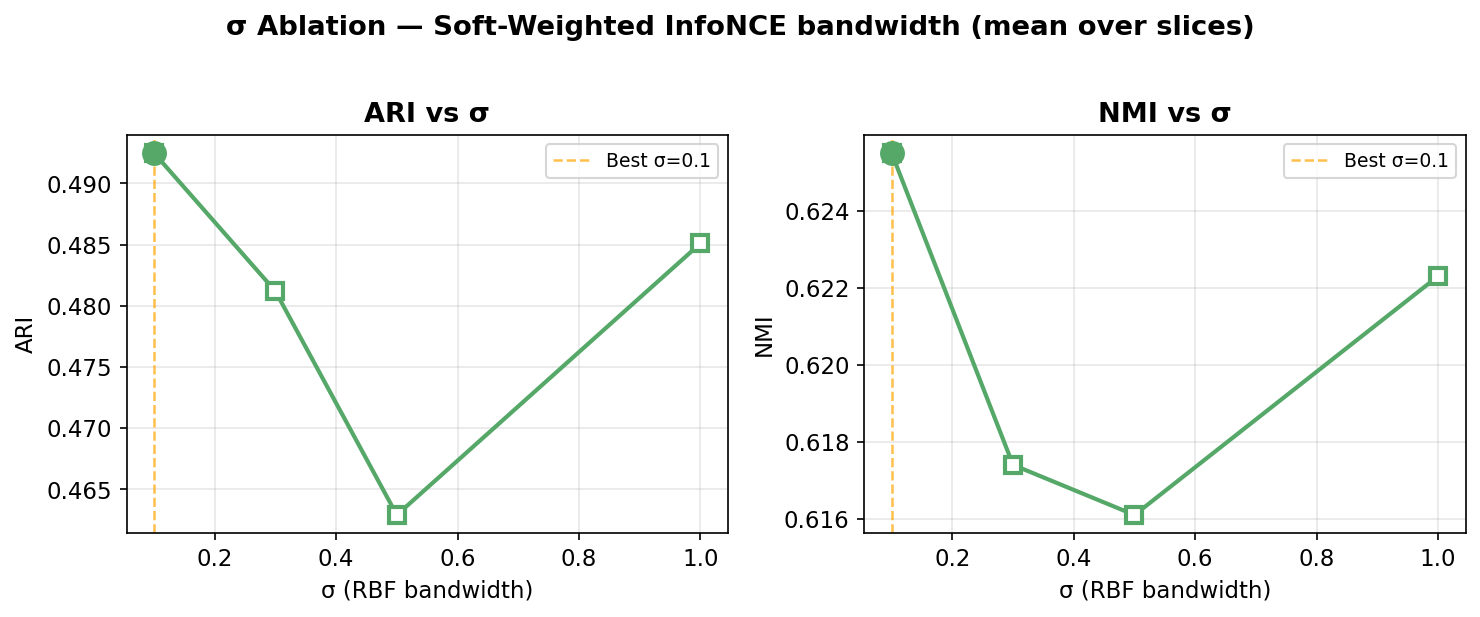

Saved: fig4_sigma_ablation.png


In [10]:
sigma_vals = [0.1,   0.3,   0.5,   1.0  ]
sigma_ari  = [0.4925,0.4812,0.4629,0.4851]
sigma_nmi  = [0.6255,0.6174,0.6161,0.6223]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, vals, ylabel in zip(axes, [sigma_ari, sigma_nmi], ['ARI', 'NMI']):
    ax.plot(sigma_vals, vals, 's-', color=COLORS['cgaston_soft'],
            linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    best_idx = np.argmax(vals)
    ax.scatter(sigma_vals[best_idx], vals[best_idx], s=120,
               color=COLORS['cgaston_soft'], zorder=5)
    ax.axvline(sigma_vals[best_idx], color='orange', linestyle='--',
               linewidth=1.2, alpha=0.7, label=f'Best σ={sigma_vals[best_idx]}')
    ax.set_xlabel('σ (RBF bandwidth)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} vs σ', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('σ Ablation — Soft-Weighted InfoNCE bandwidth (mean over slices)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_sigma_ablation.png')
plt.show()
print('Saved: fig4_sigma_ablation.png')

## Figure 5: Spatial domain maps for a representative slice
Shows ground truth, GASTON, C-GASTON Std, C-GASTON Soft side by side.

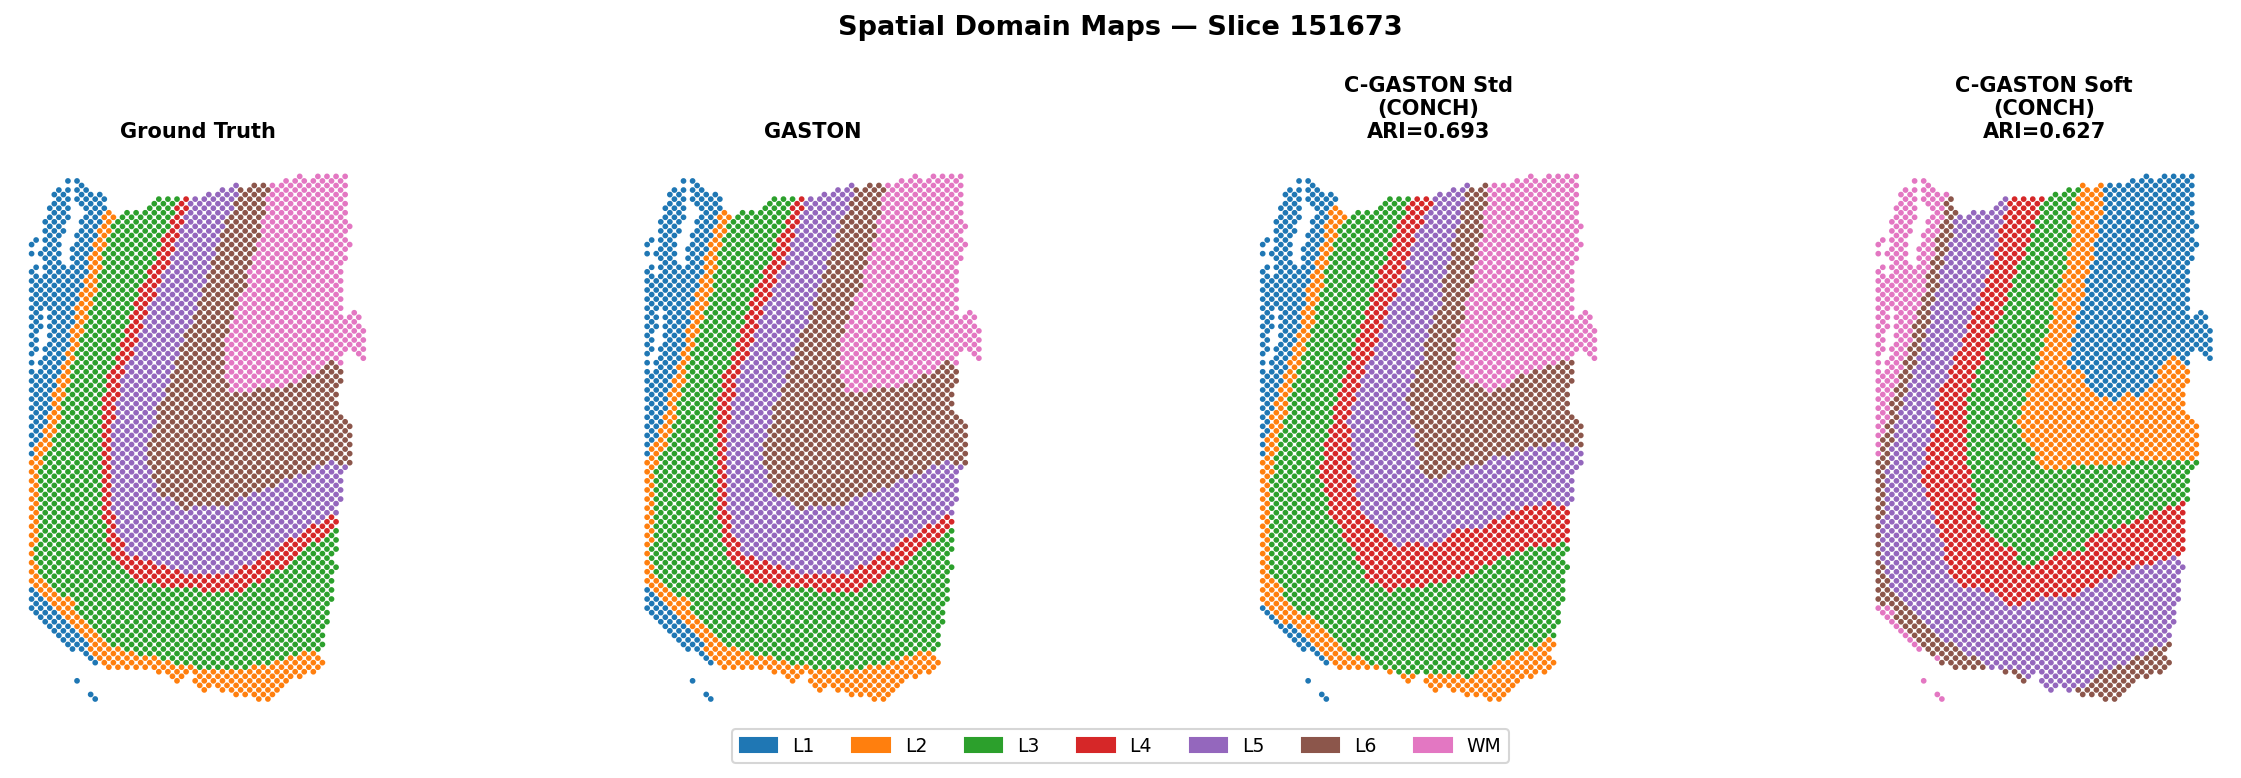

Saved: fig5_spatial_maps_151673.png


In [11]:
from sklearn.metrics import adjusted_rand_score

REP_SLICE = '151673'  # best performing slice — change if desired

coords = data[REP_SLICE]['coords']
gt     = data[REP_SLICE]['gt_labels']

panels = [
    ('Ground Truth',     gt,                                                    None),
    ('GASTON',           preds_gaston.get(REP_SLICE,    {}).get('labels', gt),  preds_gaston),
    ('C-GASTON Std\n(CONCH)', preds_conch_std.get(REP_SLICE,  {}).get('labels', gt),  preds_conch_std),
    ('C-GASTON Soft\n(CONCH)',preds_conch_soft.get(REP_SLICE, {}).get('labels', gt),  preds_conch_soft),
]

fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, (title, labels, preds_dict) in zip(axes, panels):
    sc = ax.scatter(coords[:,0], coords[:,1], c=labels,
                    cmap='tab10', vmin=0, vmax=9, s=3, rasterized=True)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')
    if preds_dict is not None and REP_SLICE in preds_dict:
        ari = adjusted_rand_score(gt[gt>=0], labels[gt>=0])
        ax.set_title(f'{title}\nARI={ari:.3f}', fontsize=10, fontweight='bold')
    else:
        ax.set_title(title, fontsize=10, fontweight='bold')

# Legend
patches = [mpatches.Patch(color=plt.cm.tab10(i/9), label=INT_TO_LABEL[i])
           for i in range(NUM_LAYERS)]
fig.legend(handles=patches, loc='lower center', ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.suptitle(f'Spatial Domain Maps — Slice {REP_SLICE}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_spatial_maps_{REP_SLICE}.png')
plt.show()
print(f'Saved: fig5_spatial_maps_{REP_SLICE}.png')

## Figure 6: Continuous isodepth maps
Shows the raw isodepth (before discretization) for the same slice.

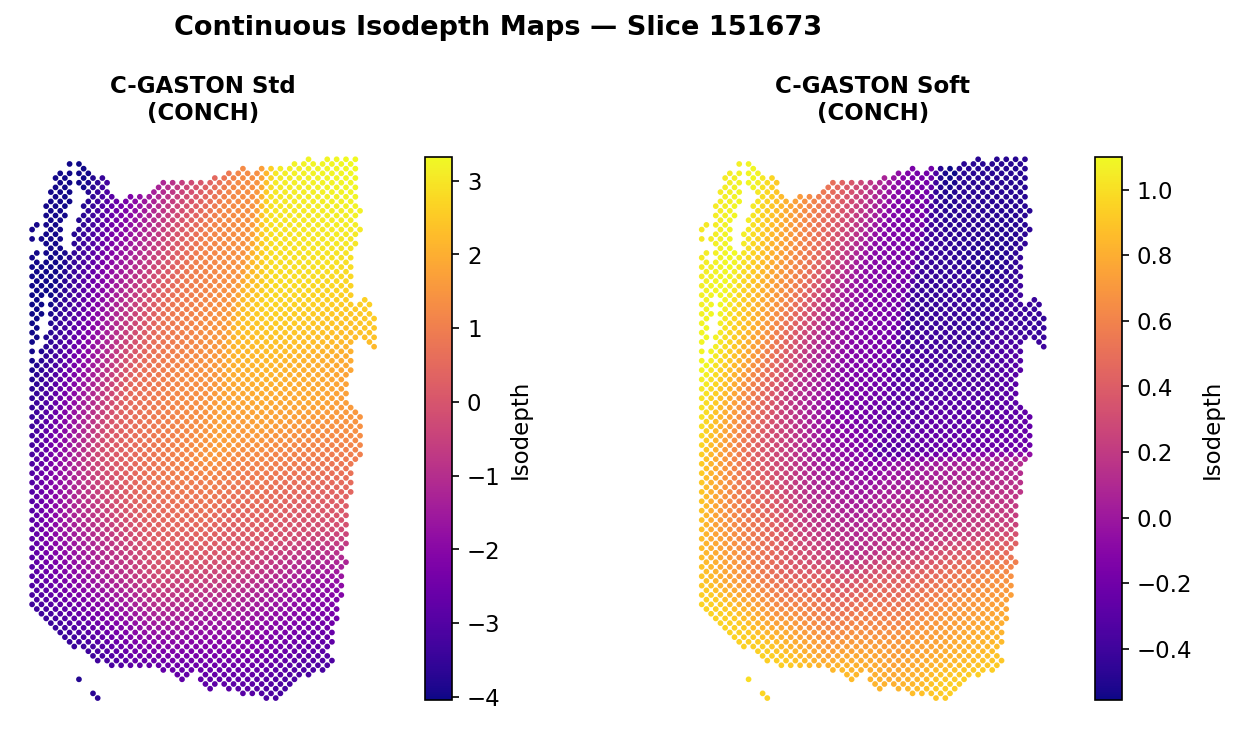

Saved: fig6_isodepth_maps_151673.png


In [12]:
iso_panels = [
    ('GASTON',            preds_gaston.get(REP_SLICE,     {}).get('isodepth')),
    ('C-GASTON Std\n(CONCH)',  preds_conch_std.get(REP_SLICE,  {}).get('isodepth')),
    ('C-GASTON Soft\n(CONCH)', preds_conch_soft.get(REP_SLICE, {}).get('isodepth')),
]
iso_panels = [(t, iso) for t, iso in iso_panels if iso is not None]

fig, axes = plt.subplots(1, len(iso_panels), figsize=(5*len(iso_panels), 5))
if len(iso_panels) == 1:
    axes = [axes]

for ax, (title, iso) in zip(axes, iso_panels):
    sc = ax.scatter(coords[:,0], coords[:,1], c=iso,
                    cmap='plasma', s=3, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.04, label='Isodepth')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle(f'Continuous Isodepth Maps — Slice {REP_SLICE}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_isodepth_maps_{REP_SLICE}.png')
plt.show()
print(f'Saved: fig6_isodepth_maps_{REP_SLICE}.png')

## Figure 7: Per-layer F1 heatmap
Shows which layers each method gets right — especially L4.

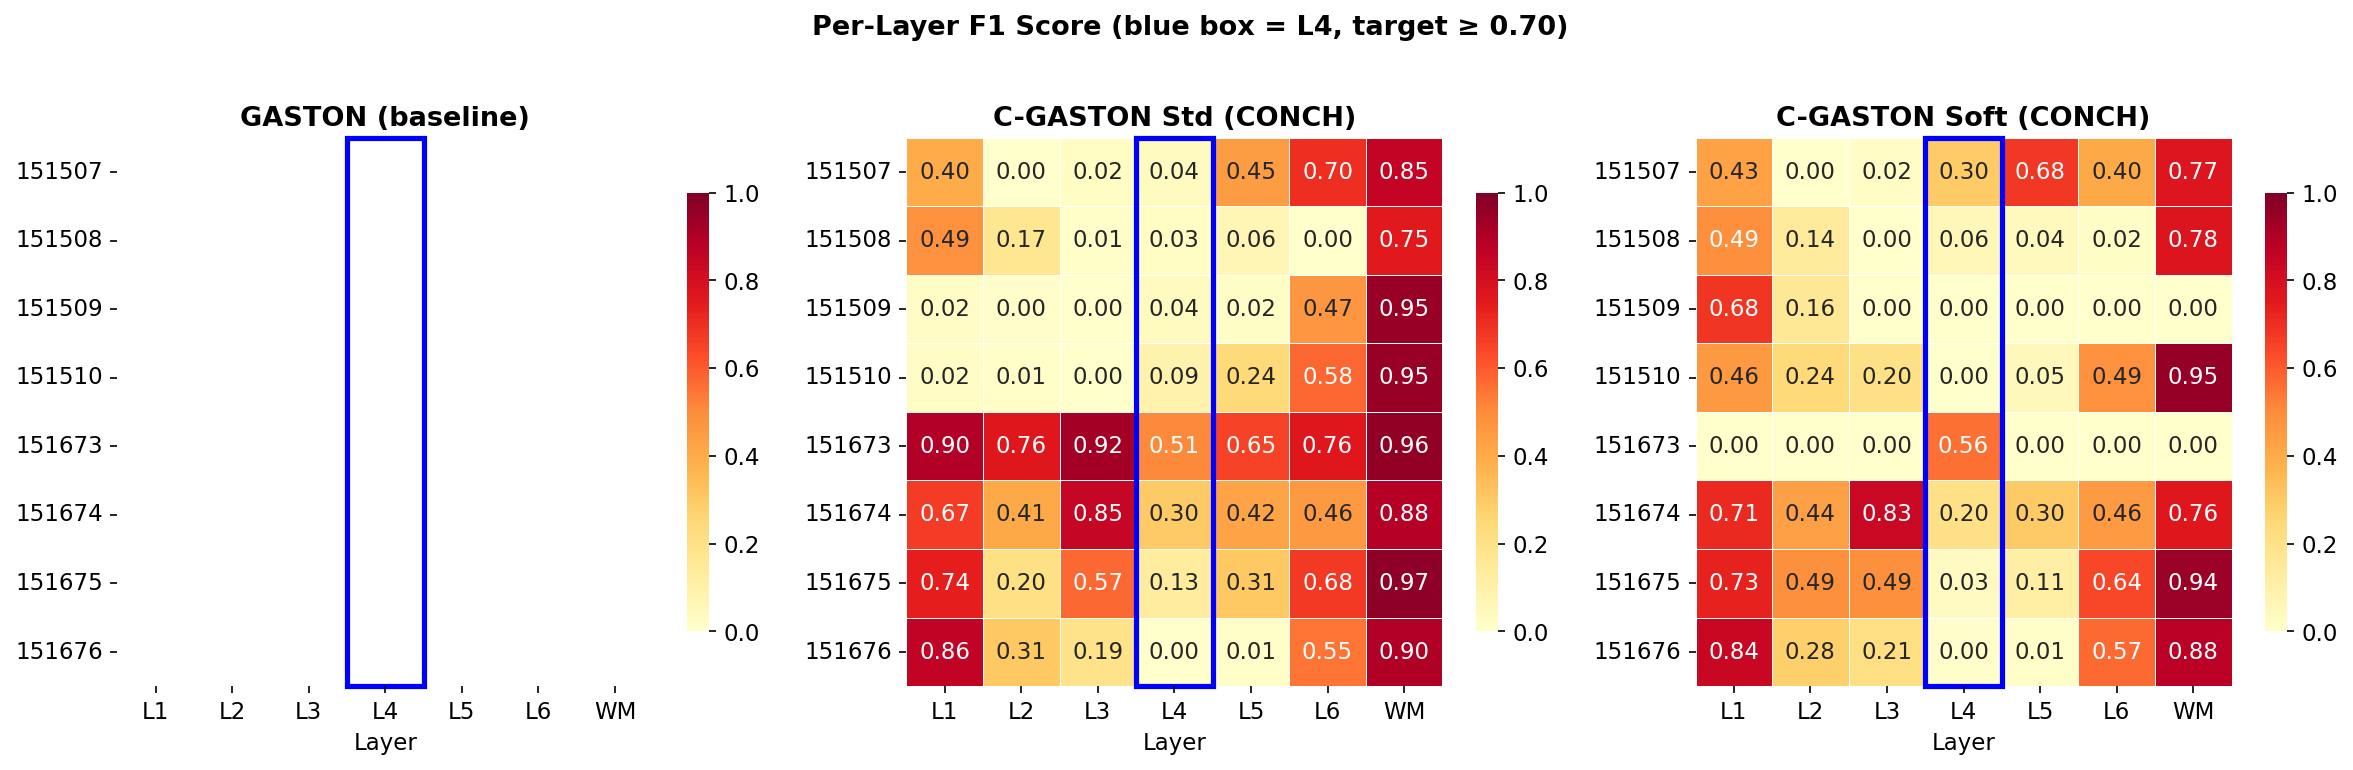

Saved: fig7_perlayer_f1_heatmap.png


In [13]:
def compute_per_layer_f1_matrix(preds_dict):
    """Returns (8 slices × 7 layers) F1 matrix."""
    rows = []
    for sid in ALL_SLICES:
        if sid not in preds_dict:
            rows.append([np.nan]*NUM_LAYERS)
            continue
        gt   = data[sid]['gt_labels']
        pred = preds_dict[sid]['labels']
        valid = gt >= 0
        f1 = f1_score(gt[valid], pred[valid], average=None,
                      labels=list(range(NUM_LAYERS)), zero_division=0)
        rows.append(f1)
    return np.array(rows)

f1_gaston    = compute_per_layer_f1_matrix(preds_gaston)
f1_conch_std = compute_per_layer_f1_matrix(preds_conch_std)
f1_conch_soft= compute_per_layer_f1_matrix(preds_conch_soft)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['GASTON (baseline)', 'C-GASTON Std (CONCH)', 'C-GASTON Soft (CONCH)']

for ax, matrix, title in zip(axes, [f1_gaston, f1_conch_std, f1_conch_soft], titles):
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=LAYER_NAMES, yticklabels=ALL_SLICES,
                vmin=0, vmax=1, ax=ax, linewidths=0.4,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    # Highlight L4
    ax.add_patch(plt.Rectangle((3,0),1,8, fill=False,
                                edgecolor='blue', lw=2.5, clip_on=False))

plt.suptitle('Per-Layer F1 Score (blue box = L4, target ≥ 0.70)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig7_perlayer_f1_heatmap.png')
plt.show()
print('Saved: fig7_perlayer_f1_heatmap.png')

## Figure 8: ARI improvement over GASTON (ΔARI)
Shows where C-GASTON helps and where it doesn't.

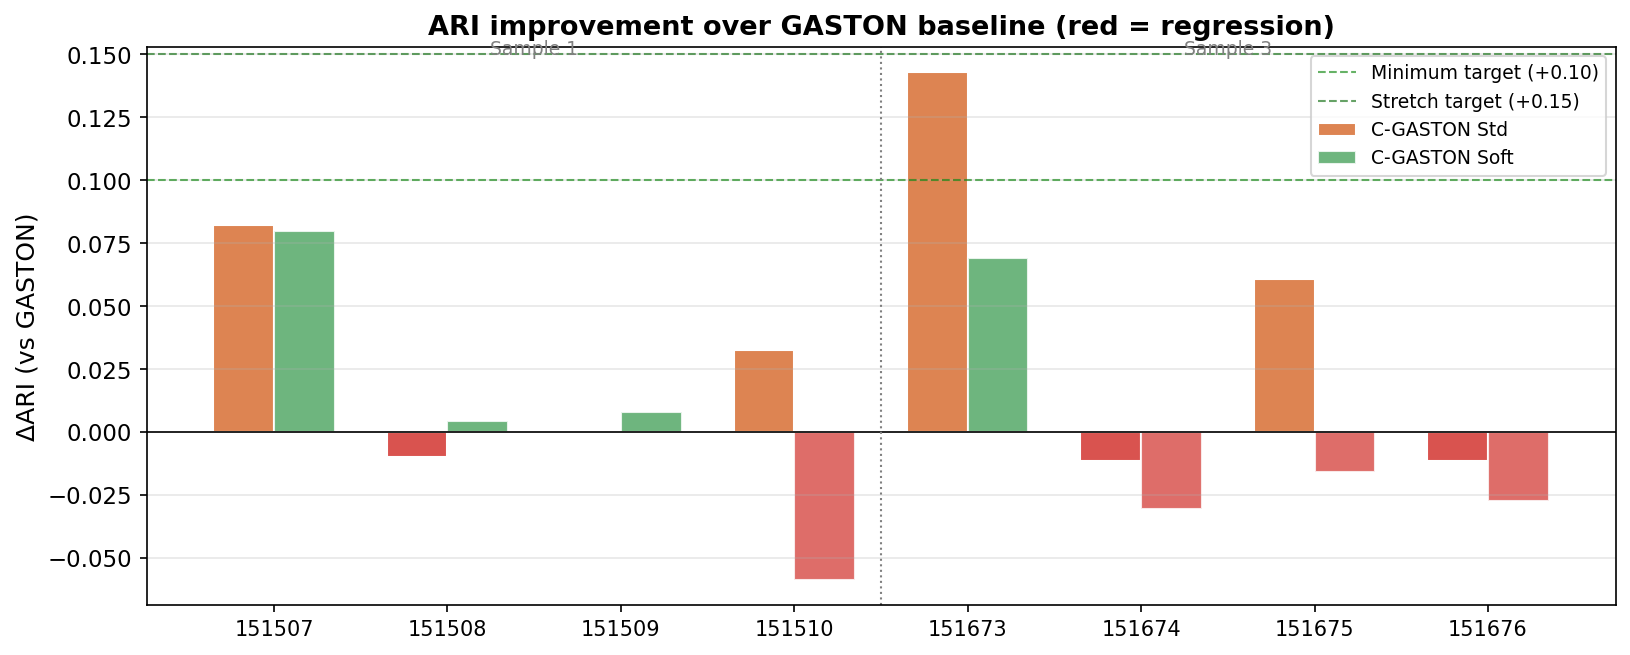

Saved: fig8_delta_ari.png


In [14]:
gaston_aris    = [0.3998,0.4174,0.3891,0.3448,0.5575,0.5112,0.4342,0.5567]
cgaston_std    = [0.4819,0.4076,0.3884,0.3775,0.7003,0.4997,0.4949,0.5451]
cgaston_soft   = [0.4796,0.4216,0.3971,0.2860,0.6266,0.4806,0.4184,0.5293]

delta_std  = [c-g for c,g in zip(cgaston_std,  gaston_aris)]
delta_soft = [c-g for c,g in zip(cgaston_soft, gaston_aris)]

x  = np.arange(len(ALL_SLICES))
w  = 0.35
fig, ax = plt.subplots(figsize=(11, 4.5))

bars1 = ax.bar(x - w/2, delta_std,  w, label='C-GASTON Std',
               color=[COLORS['cgaston_std']  if d>=0 else '#d9534f' for d in delta_std],
               edgecolor='white')
bars2 = ax.bar(x + w/2, delta_soft, w, label='C-GASTON Soft',
               color=[COLORS['cgaston_soft'] if d>=0 else '#d9534f' for d in delta_soft],
               edgecolor='white', alpha=0.85)

ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline(0.10, color='green', linestyle='--', linewidth=1,
           alpha=0.6, label='Minimum target (+0.10)')
ax.axhline(0.15, color='darkgreen', linestyle='--', linewidth=1,
           alpha=0.6, label='Stretch target (+0.15)')
ax.axvline(3.5, color='grey', linestyle=':', linewidth=1)
ax.text(1.5,  max(delta_std+delta_soft)*1.05, 'Sample 1', ha='center', color='grey', fontsize=9)
ax.text(5.5,  max(delta_std+delta_soft)*1.05, 'Sample 3', ha='center', color='grey', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ALL_SLICES, fontsize=10)
ax.set_ylabel('ΔARI (vs GASTON)', fontsize=12)
ax.set_title('ARI improvement over GASTON baseline (red = regression)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig8_delta_ari.png')
plt.show()
print('Saved: fig8_delta_ari.png')

## Figure 9: Radar / Spider chart — all metrics by method
Gives a holistic view across ARI, NMI, Spearman, Boundary Precision.

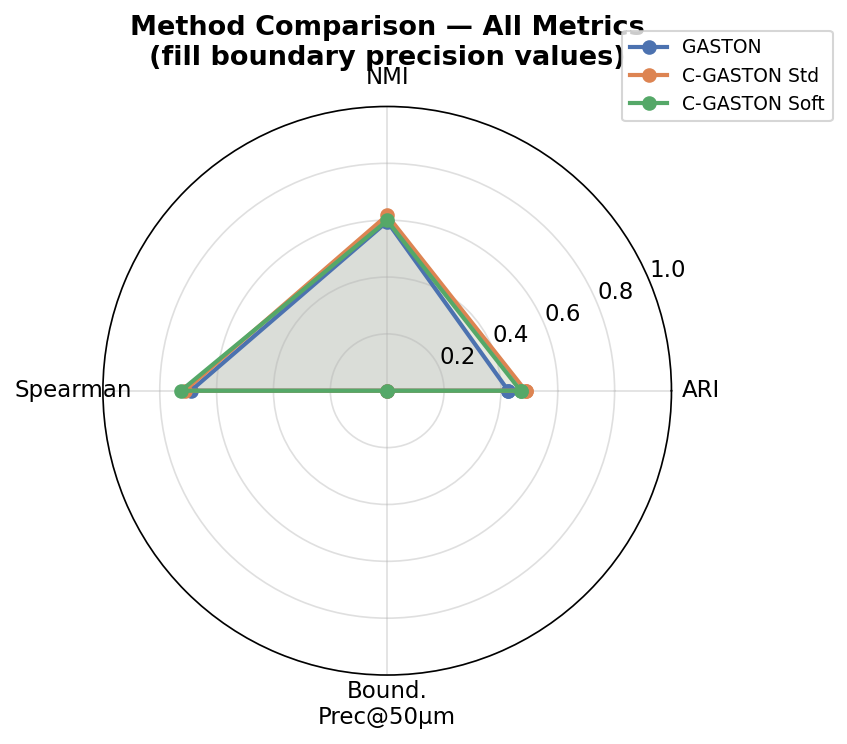

Saved: fig9_radar_chart.png
NOTE: Update boundary precision values (index 3) in radar_data before using in report.


In [15]:
# Fill in your computed values
# Boundary precision values — replace with your actual computed numbers
radar_metrics = ['ARI', 'NMI', 'Spearman', 'Bound.\nPrec@50µm']
radar_data = {
    'GASTON':        [0.4263, 0.5950, 0.6912, 0.00],  # replace BP
    'C-GASTON Std':  [0.4870, 0.6175, 0.7129, 0.00],  # replace BP
    'C-GASTON Soft': [0.4695, 0.5989, 0.7255, 0.00],  # replace BP
}
# NOTE: fill in the boundary precision values (index 3) from your stats notebook output

n = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
method_colors = [COLORS['gaston'], COLORS['cgaston_std'], COLORS['cgaston_soft']]

for (method, vals), color in zip(radar_data.items(), method_colors):
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, 'o-', linewidth=2, color=color, label=method)
    ax.fill(angles, vals_closed, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Method Comparison — All Metrics\n(fill boundary precision values)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig9_radar_chart.png')
plt.show()
print('Saved: fig9_radar_chart.png')
print('NOTE: Update boundary precision values (index 3) in radar_data before using in report.')

## Figure 10: Summary — all figures saved

In [16]:
print('=' * 55)
print('All figures saved to:', FIG_DIR)
print('=' * 55)
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith('.png'):
        print(f'  {f}')
print()
print('Recommended for report:')
print('  fig1  — main ARI result (use in Results section)')
print('  fig2  — backbone comparison (use in Ablation section)')
print('  fig3  — lambda ablation (use in Ablation section)')
print('  fig4  — sigma ablation (use in Ablation section)')
print('  fig5  — spatial maps, best slice (use in Results section)')
print('  fig6  — isodepth maps (use in Methods section)')
print('  fig7  — per-layer F1 heatmap (use in Results section)')
print('  fig8  — delta ARI (use in Discussion section)')
print('  fig9  — radar chart (use in Conclusion/Abstract)')

All figures saved to: /content/drive/MyDrive/C_GASTON_figures
  fig1_ari_per_slice.png
  fig2_backbone_comparison.png
  fig3_lambda_ablation.png
  fig4_sigma_ablation.png
  fig5_spatial_maps_151673.png
  fig6_isodepth_maps_151673.png
  fig7_perlayer_f1_heatmap.png
  fig8_delta_ari.png
  fig9_radar_chart.png

Recommended for report:
  fig1  — main ARI result (use in Results section)
  fig2  — backbone comparison (use in Ablation section)
  fig3  — lambda ablation (use in Ablation section)
  fig4  — sigma ablation (use in Ablation section)
  fig5  — spatial maps, best slice (use in Results section)
  fig6  — isodepth maps (use in Methods section)
  fig7  — per-layer F1 heatmap (use in Results section)
  fig8  — delta ARI (use in Discussion section)
  fig9  — radar chart (use in Conclusion/Abstract)
